# Continuous Normalizing Flows

## Goal

Learn a time-dependent velocity field that transports a standard Gaussian to the two-moons distribution, then verify that numerical forward and reverse integration are consistent.

## 1. From layers to an ODE

A continuous normalizing flow defines a trajectory $z(t)$ through

$$\frac{d z(t)}{dt}=v_\theta(t,z(t)).$$

The log-density changes according to the instantaneous divergence of the velocity field. This implementation computes the divergence exactly in one and two dimensions and uses Hutchinson's trace estimator above two dimensions. The map is therefore numerical: accuracy depends on the ODE solver and step size.

In [5]:
import matplotlib.pyplot as plt
import torch
from torch.distributions import MultivariateNormal

from src.flows import ContinuousFlow
from src.utils import get_two_moons_data

torch.manual_seed(0)

device = torch.device("cpu")
data_dim = 2
n_samples = 300
hidden_dim = 64
epochs = 120
learning_rate = 2e-2

data = get_two_moons_data(n_samples=n_samples).to(device)
base = MultivariateNormal(
    torch.zeros(data_dim, device=device),
    torch.eye(data_dim, device=device),
)
model = ContinuousFlow(data_dim, hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(f"device={device}, samples={len(data):,}")

device=cpu, samples=300


## 2. Train by maximum likelihood

The inverse ODE maps observations to the Gaussian base. Full-batch training keeps this small tutorial deterministic and avoids repeatedly solving the ODE for many mini-batches.

In [6]:
history = []
model.train()

for epoch in range(epochs):
    latent, log_det = model.inverse(data)
    loss = -(base.log_prob(latent) + log_det).mean()

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
    optimizer.step()

    history.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch + 1:2d}: NLL={loss.item():.3f}")

epoch 10: NLL=1.985
epoch 20: NLL=1.947
epoch 30: NLL=1.887
epoch 40: NLL=1.927
epoch 50: NLL=1.686
epoch 60: NLL=1.499
epoch 70: NLL=1.549
epoch 80: NLL=1.339
epoch 90: NLL=1.295
epoch 100: NLL=1.272
epoch 110: NLL=1.279
epoch 120: NLL=1.255


## 3. Inspect the transported samples

The model starts at the Gaussian base at $t=0$ and integrates the learned velocity field to $t=1$.

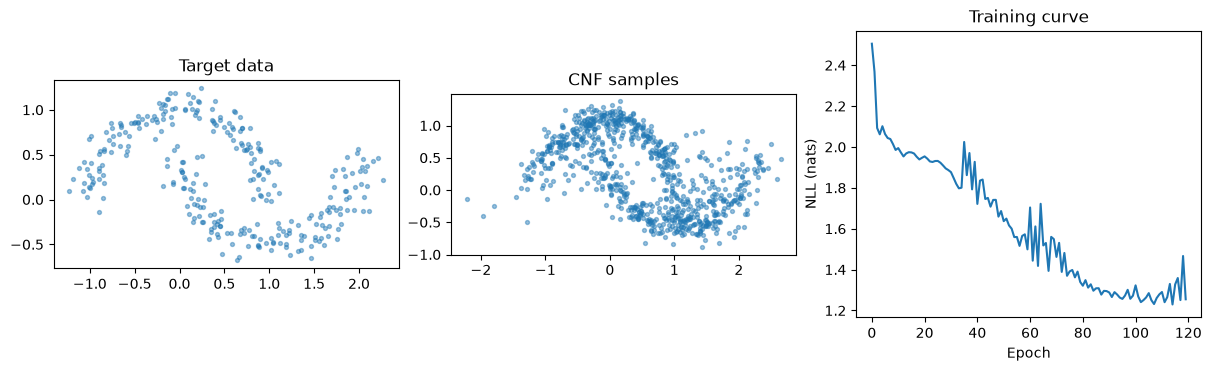

In [7]:
model.eval()
with torch.no_grad():
    generated, _ = model.forward(base.sample((800,)))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)
axes[0].scatter(data[:, 0], data[:, 1], s=8, alpha=0.45)
axes[0].set_title("Target data")
axes[1].scatter(generated[:, 0], generated[:, 1], s=8, alpha=0.45)
axes[1].set_title("CNF samples")
axes[2].plot(history)
axes[2].set(title="Training curve", xlabel="Epoch", ylabel="NLL (nats)")

for axis in axes[:2]:
    axis.set_aspect("equal")
plt.show()

## 4. Numerical checks

Unlike a discrete algebraic inverse, an ODE round trip accumulates integration error. The tolerance below tests the current fixed-step solver rather than expecting machine precision.

In [8]:
with torch.no_grad():
    latent, inverse_logdet = model.inverse(data[:64])
    reconstructed, forward_logdet = model.forward(latent)

reconstruction_error = (reconstructed - data[:64]).abs().max().item()
logdet_error = (forward_logdet + inverse_logdet).abs().max().item()

assert reconstruction_error < 5e-3
assert logdet_error < 5e-3
print(f"max reconstruction error={reconstruction_error:.2e}")
print(f"max logdet cancellation error={logdet_error:.2e}")

max reconstruction error=6.56e-07
max logdet cancellation error=1.07e-06


## Next steps

Vary the integration step size and compare runtime, NLL, reconstruction error, and log-determinant cancellation. Above two dimensions, repeat the calculation across several Hutchinson trace samples to observe estimator variance.